In [1]:
import sys

sys.path.append("../src/")

import h5py
import matplotlib.pyplot as plt
import mrcfile
from cryosim import rotations
import torch
from cryosim.filters import apply_bfactor, butter, chimera_gaussian_sigma_to_bfactor
from cryosim.imagegenerator import ImageGenerator
from cryosim.pdb2mrc import PDB2MRC
from cryosim.plotting_tools import *
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

In [2]:
fft2 = lambda array: torch.fft.fftshift(torch.fft.fft2(torch.fft.ifftshift(array)))
ifft2 = lambda array: torch.fft.fftshift(torch.fft.ifft2(torch.fft.ifftshift(array)))

## Create 3D scattering potential

In [3]:
# fetch pdb file
pdb_code = "6bdf"
pm = PDB2MRC(pdb_code)
pm.fetch_pdb(pdb_folder="../pdb-data/")

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.
Parsing ../pdb-data/6bdf-assembly1.cif.


Extracting atom coordinates and element: 46382it [00:00, 172157.50it/s]


In [4]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 1.0  # angstrom, pixel size.
pm.build_particle(n=n, dx=dx)
V = pm.particle.detach().clone()

Building element S: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  6.20it/s]


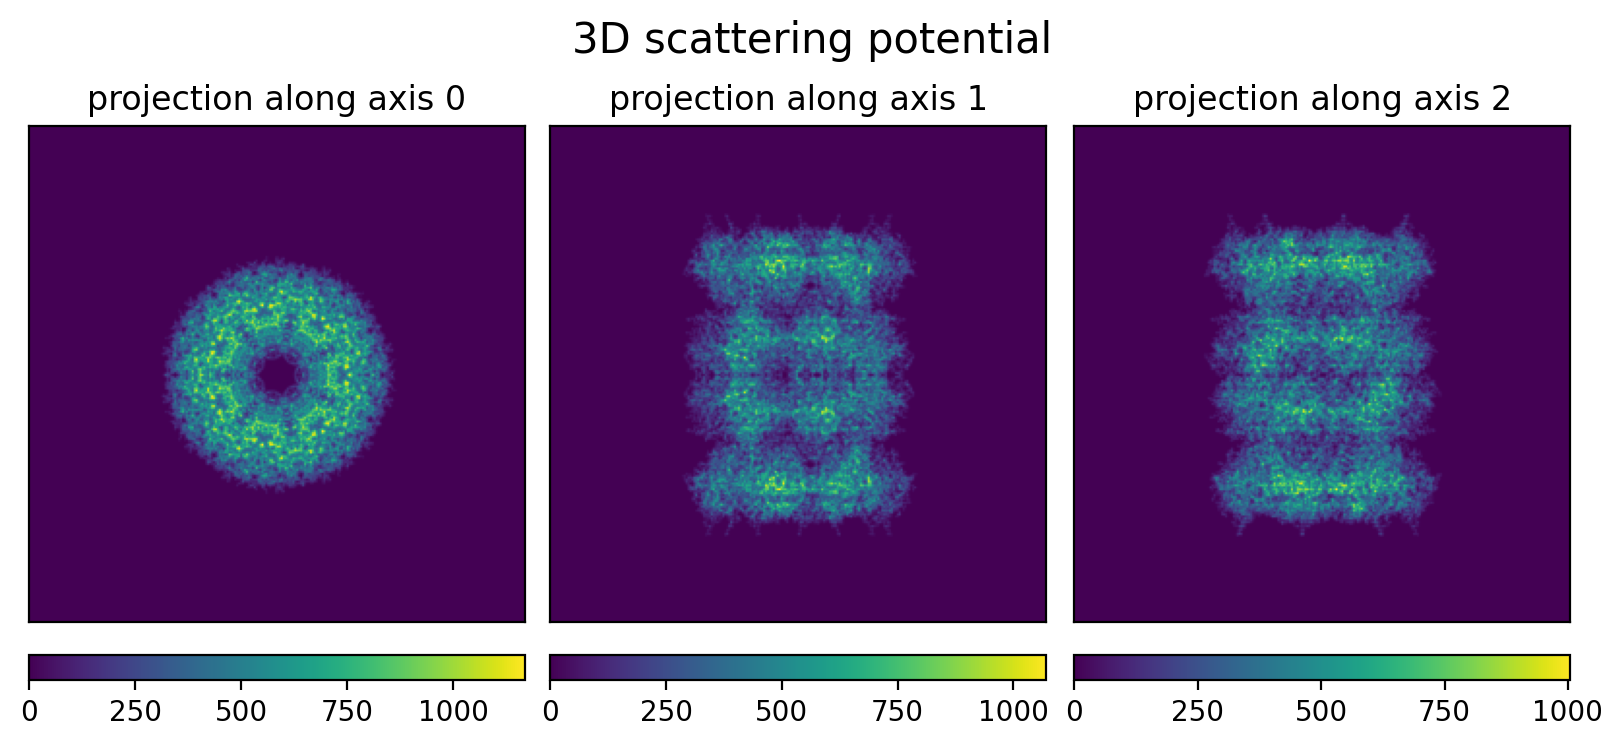

In [5]:
plot3d(V, title="3D scattering potential")

In [6]:
# with mrcfile.open('/scratch/loh/joel/thermofisher/adrian_aav9_new.mrc') as mrc:
#     V = torch.as_tensor(mrc.data.copy())
# V.shape

In [7]:
# with mrcfile.new("/scratch/loh/joel/empiar-12391/8s7j_448x448x448_I1.mrc",
#     overwrite=True,
# ) as mrc:
#     mrc.set_data(V.cpu().numpy())
#     mrc.voxel_size = dx

## Manual rotation of 3D scattering potential (if you want)
Only if you want to pre-rotate the 3D potential before simulating images.

Use-case: maybe you want to simulate in-plane rotations of a different view of the particle.

In [8]:
# y-plane rotation for e.g.
# rotation_angle = torch.tensor(torch.pi / 2)
# rotation_quaternion = torch.tensor(
#     [0, torch.sin(rotation_angle / 2), 0, torch.cos(rotation_angle / 2)]
# )
# rotation_matrix = rotations.quaternion_to_rotation_matrix(rotation_quaternion[None,...])
# affine_matrix = rotations.build_affine_matrix(rotation_matrix, torch.zeros(1,3))
# rotated_V = rotations.rotate_volume(V, affine_matrix)

In [9]:
# plot3d(rotated_V.squeeze(), title="rotated V")

## Generate dataset
Here, you can choose to either use random or in-plane rotations, and random or fixed defocus values (comment/uncomment respectively).

In [10]:
# chimera_gaussian_sigma_to_bfactor(0.8)

In [11]:
bfactor = 50
filtered = apply_bfactor(V, dx, bfactor)

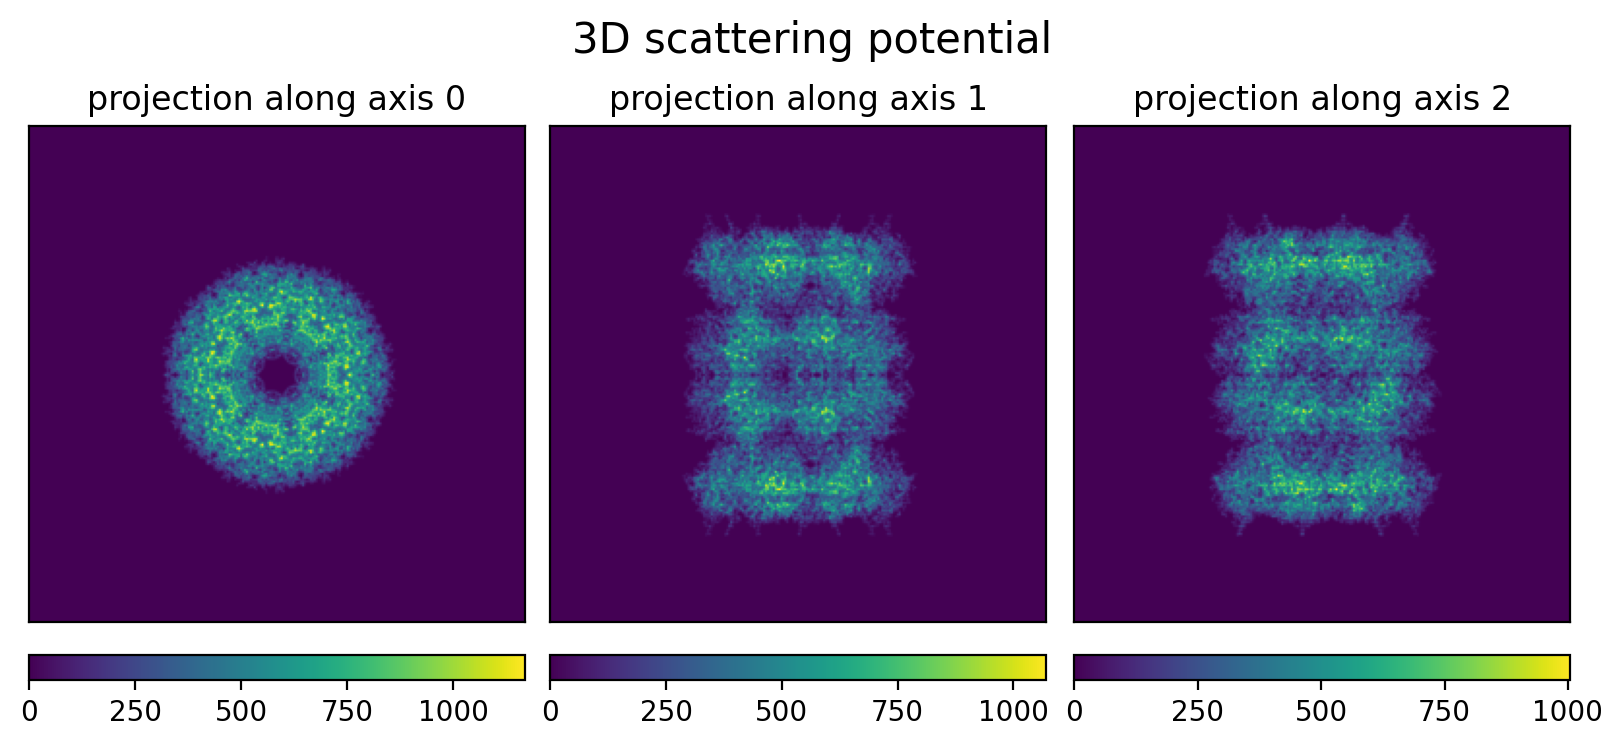

In [12]:
plot3d(V, title="3D scattering potential")

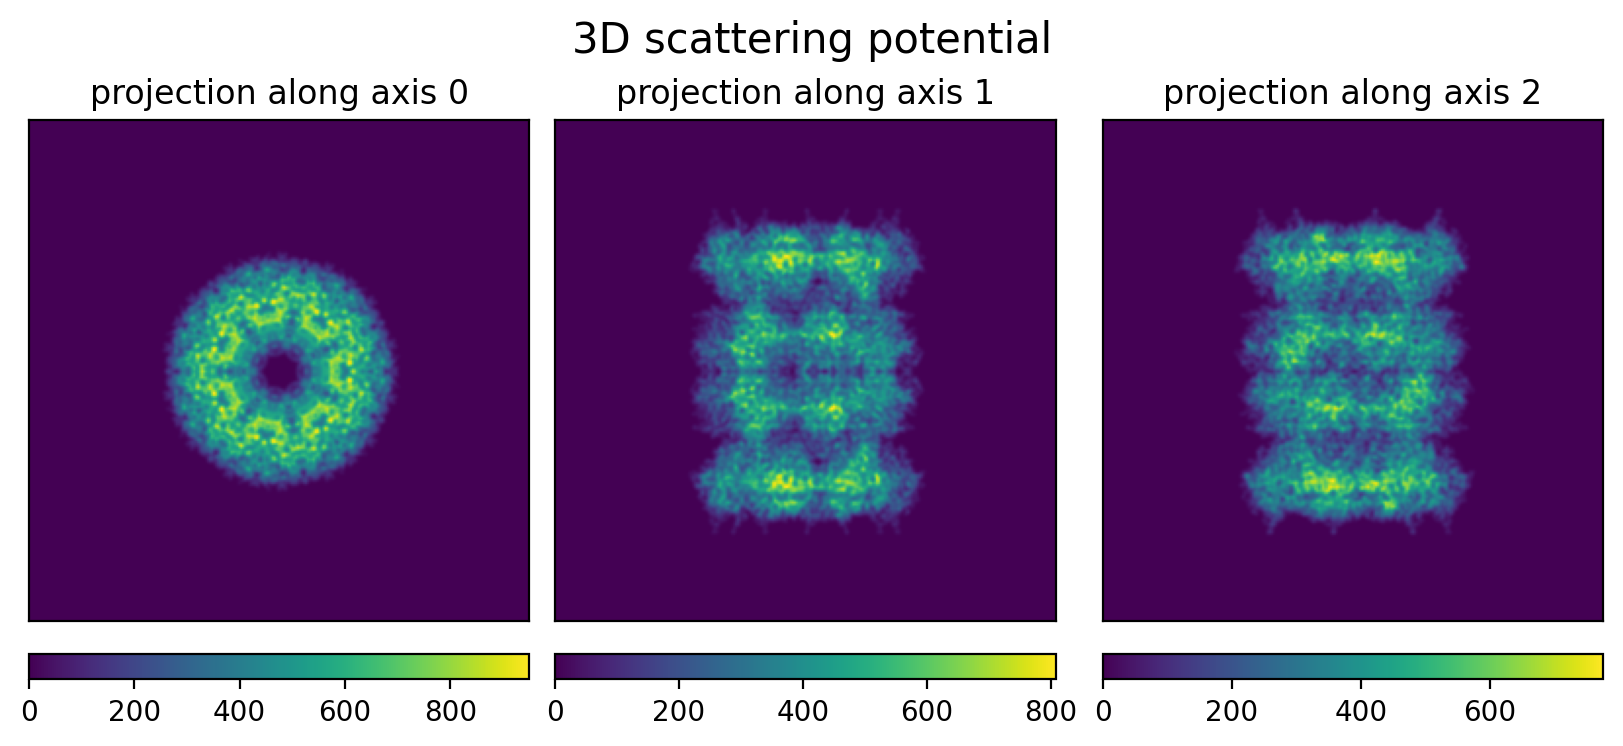

In [13]:
plot3d(filtered, title="3D scattering potential")

In [14]:
n_particles = 10
energy = 100  # keV
dose_per_angstrom = 40  # e-/A^2
Cs = 1.5857857e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1

In [15]:
# random quaternions
quaternions = torch.stack([rotations.random_quaternion() for i in range(n_particles)])

# in-plane rotations (around z-axis)
# angles = torch.linspace(0, 360, n_particles + 1)
# angles = angles[:-1] / 180 * torch.pi
# quaternions = []
# for a in angles:
#     # (x,y,z,w)
#     quaternions.append(torch.tensor([0, 0, torch.sin(a / 2), torch.cos(a / 2)]))
# quaternions = torch.stack(quaternions)

quaternions.shape

torch.Size([10, 4])

In [20]:
# random defocus
defocus_min = 5000  # angstrom
defocus_max = 25000  # angstrom
dfang = 0
defocus_A = torch.rand(n_particles) * (defocus_max - defocus_min) + defocus_min

# fixed defocus
# defocus_A = 10000 * torch.ones(n_particles)

# beamtilt
tiltx = 0.0
tilty = 0.0

# beamtilt
tref1 = 0.0
tref2 = 0.0

phaseshift = 0.0

ctf_params = torch.stack(
    [torch.tensor([Cs, d, d, dfang, tiltx, tilty, phaseshift, tref1, tref2]) for d in defocus_A]
)
ctf_params.shape

torch.Size([10, 9])

In [21]:
# random shift. set to 0 for no shifts
shift = 0.0  # A
rlnOriginXAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
rlnOriginYAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
translations = torch.stack([rlnOriginXAngst, rlnOriginYAngst], dim=-1)
translations.shape

torch.Size([10, 2])

In [22]:
device = "cuda:1"  # choose cpu if you run out of cuda memory.

In [23]:
# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'
noise_model = None  # 'poisson' or None
ice_model = None  # 'randomchoice' or None
ice_thickness = 0  # angstroms
model = ImageGenerator(
    # V,  # or rotated_V
    filtered,  # or rotated_V
    dx,
    quaternions,
    translations,
    ctf_params,
    energy,
    dose_per_angstrom,
    ice_model=ice_model,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    flip_curvature=False,
    alpha=alpha,
).to(device)

In [24]:
idx = torch.arange(n_particles)  # new
images = []
batchsize = 5  # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in tqdm(range(0, n_particles, batchsize)):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  5.79it/s]


torch.Size([10, 256, 256])

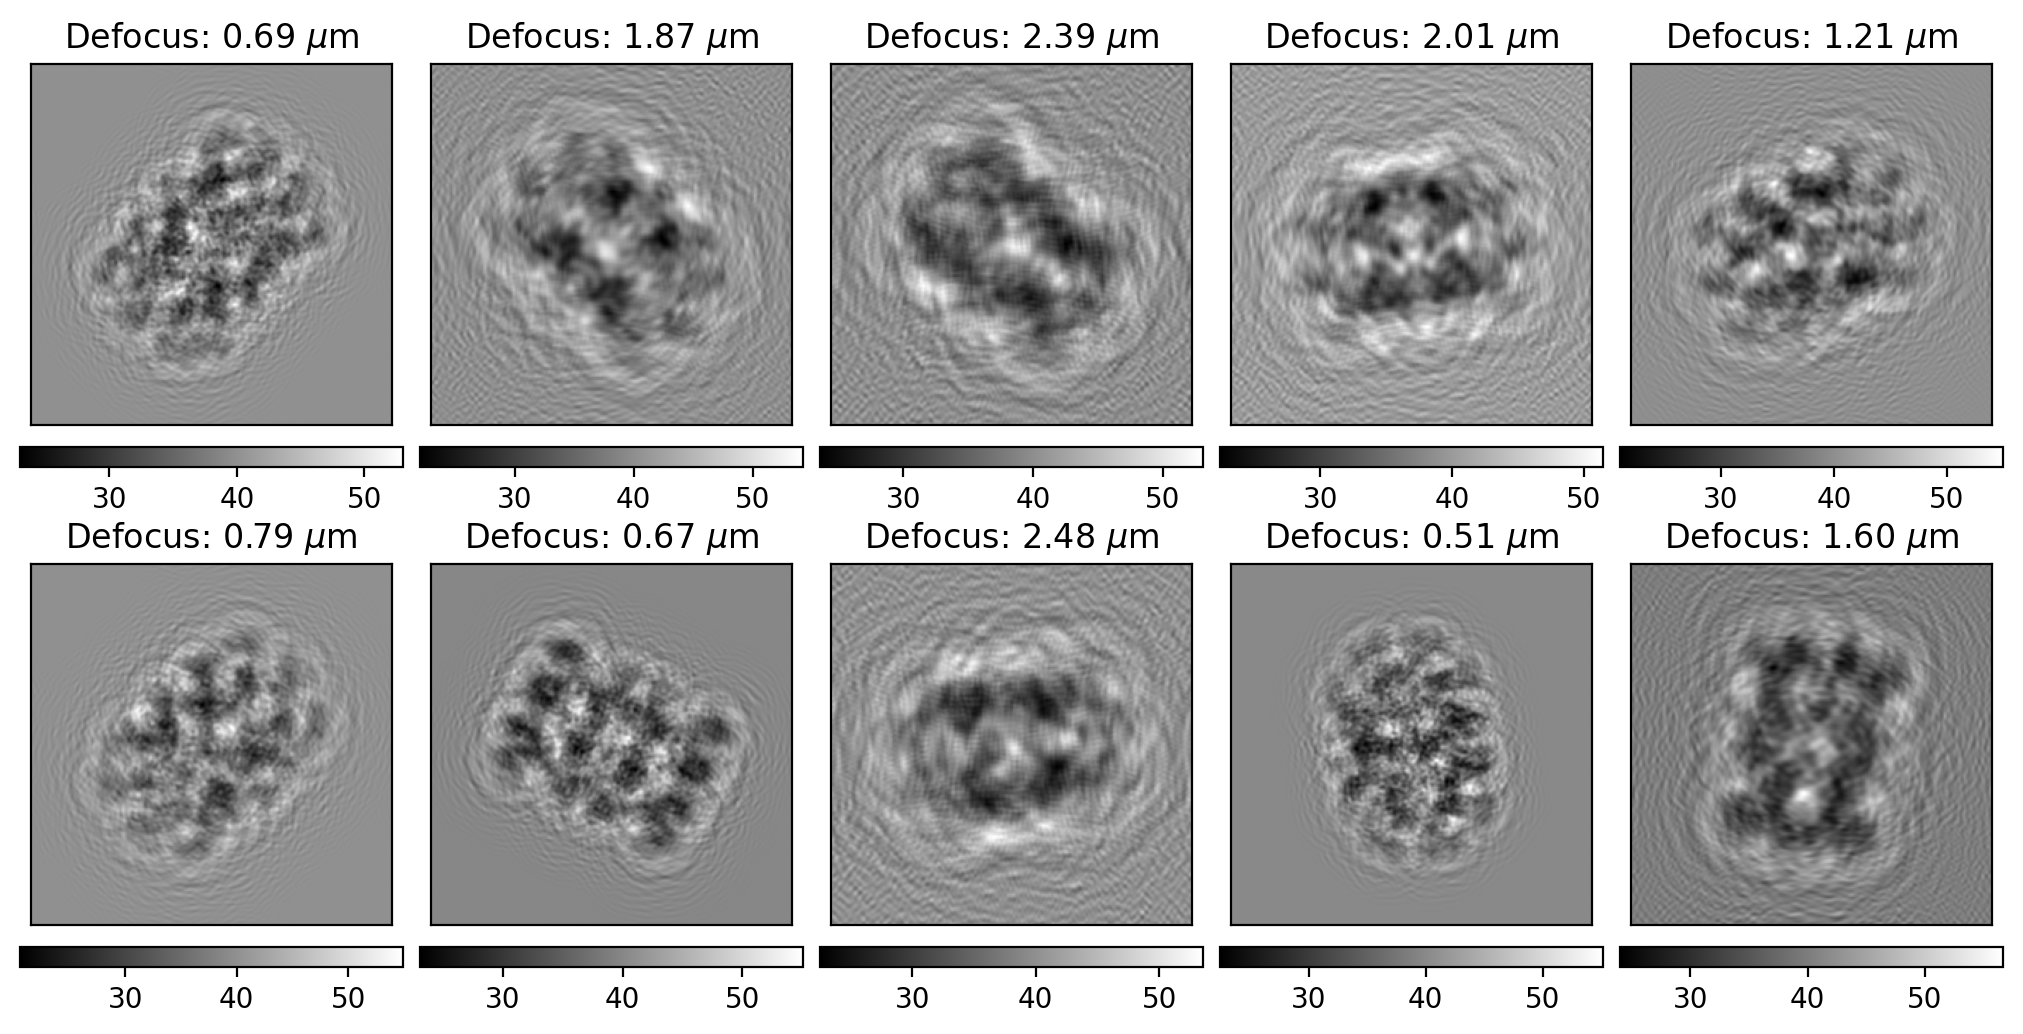

In [25]:
fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow((images[i]), cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params[i,2]/10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

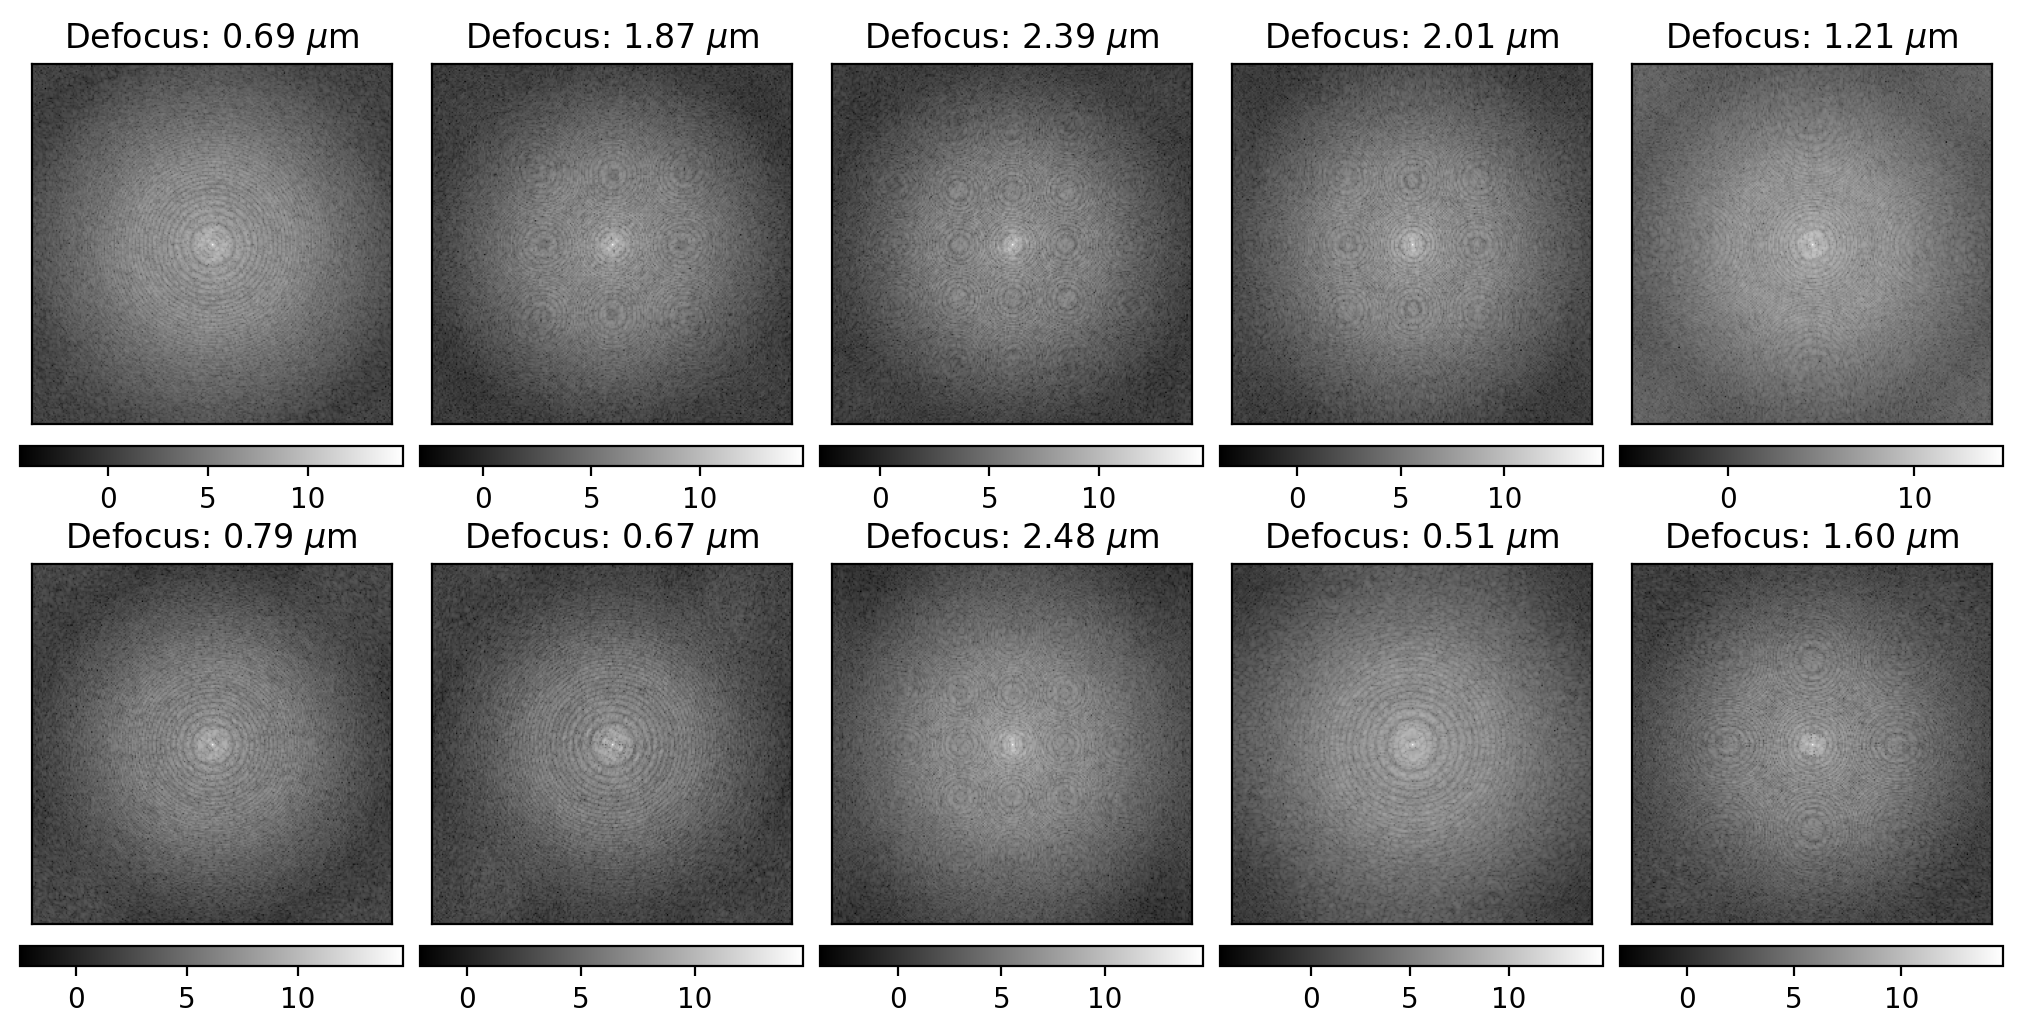

In [26]:
fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(torch.log(torch.abs(fft2(images[i]))), cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params[i,2]/10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

In [27]:
filename = f"/scratch/loh/joel/cryosparc-troubleshoot/T20S_check_cryosim_3D_reconstruction_29apr2025.h5"

In [ ]:
with h5py.File(filename, "w") as f:
    f["data/intensities"] = images.detach().cpu().numpy()
    f["data/defocus_A"] = defocus_A
    f["data/orientations"] = quaternions.detach().cpu().numpy()
    f["data/rlnOriginYAngst"] = rlnOriginYAngst
    f["data/rlnOriginXAngst"] = rlnOriginXAngst
    f["params/alpha"] = alpha
    f["params/energy"] = energy
    f["params/cs"] = Cs
    f["params/roi"] = (n, n)
    f["params/dx"] = dx
    f["params/dose_per_angstrom"] = dose_per_angstrom
    f["params/bfactor"] = bfactor

In [ ]:
from scipy.spatial.transform import Rotation
import pandas as pd
import starfile

def create_cryosparc_reconstruct_starfile(
    particles=None,
    euler_angles=None,
    alpha=None,
    energy=None,
    Cs=None,
    pixel_size=None,
    filename="particles",
    defocusU=None,
    defocusV=None,
    defocusAngle=None,
    originXAngst=None,
    originYAngst=None,
):
    # create projections mrcs file
    if particles is not None:
        mrcs_path = filename + ".mrcs"
        with mrcfile.new(mrcs_path, overwrite=True) as mrc:
            mrc.set_data(particles.numpy())

    # create associated starfile
    d = {}
    if particles is not None:
        n = len(particles)
        d["rlnImageName"] = [str(i) + "@" + filename + ".mrcs" for i in range(1, n + 1)]
    if energy is not None:
        d["rlnVoltage"] = energy
    if Cs is not None:
        d["rlnSphericalAberration"] = Cs  # in [mm]
    if alpha is not None:
        d["rlnAmplitudeContrast"] = alpha
    if pixel_size is not None:
        d["rlnDetectorPixelSize"] = pixel_size
    if euler_angles is not None:
        d["rlnAngleRot"] = euler_angles[:, 0]
        d["rlnAngleTilt"] = euler_angles[:, 1]
        d["rlnAnglePsi"] = euler_angles[:, 2]
    if defocusU is not None:
        d["rlnDefocusU"] = defocusU
        if defocusV is None:
            d["rlnDefocusV"] = defocusU
            d["rlnDefocusAngle"] = [0] * n
    if defocusV is not None:
        d["rlnDefocusV"] = defocusV
        d["rlnDefocusAngle"] = defocusAngle
    if originXAngst is not None:
        d["rlnOriginXAngst"] = originXAngst
    if originYAngst is not None:
        d["rlnOriginYAngst"] = originYAngst

    df = pd.DataFrame(data=d)

    star_path = filename + ".star"
    starfile.write(df, star_path, overwrite=True)


R = Rotation.from_quat(quaternions)
euler_angles = R.as_euler("ZYZ", degrees=True)

create_cryosparc_reconstruct_starfile(
    filename='test',
    particles=images,
    euler_angles=euler_angles,
    alpha=alpha,
    energy=energy,
    Cs=Cs/1e7, #in [mm]
    pixel_size=dx,
    defocusU=ctf_params[:,1],
    defocusV=ctf_params[:,2],
    defocusAngle=ctf_params[:,3],
    originXAngst=rlnOriginXAngst,
    originYAngst=rlnOriginYAngst
)

In [ ]:

R = Rotation.from_quat(quaternions)
euler_angles = R.as_euler("ZYZ", degrees=True)

create_cryosparc_reconstruct_starfile(
    filename='test',
    particles=images,
    euler_angles=euler_angles,
    alpha=alpha,
    energy=energy,
    Cs=Cs/1e7, #in [mm]
    pixel_size=dx,
    defocusU=ctf_params[:,1],
    defocusV=ctf_params[:,2],
    defocusAngle=ctf_params[:,3],
    originXAngst=rlnOriginXAngst,
    originYAngst=rlnOriginYAngst
)